In [ ]:
# -*- coding: utf-8 -*-
"""
A demonstration benchmarks the MCU-Quake (5-20) using 100 samples from the UUSS dataset. The full data are provided in the Data Availability section of the manuscript. 

Note that the performance of MCU-Quake can be improved by employing a more sophisticated interpretation method for the model's output embeddings.
"""


from Library import utils, dataset
import pandas as pd
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import config

def plot_save_mismatches(plot_func, mismatch_pred, name_mismatch_pred,
                         source_data, source_meta,
                         plot_num, save_dir,
                         input_win=None):
        # save fig dir
    if len(mismatch_pred)>1:
        _plot_num = min(plot_num, len(mismatch_pred))
        _fig_dir = os.path.join(save_dir, f"Figures, {name_mismatch_pred.split('.')[0]}")
        if not os.path.exists(_fig_dir): os.makedirs(_fig_dir)
        _id_list = np.random.choice(list(mismatch_pred.keys()), size=_plot_num, replace=False)
        plot_func(_id_list, source_data, source_meta,
                  pred_info=mismatch_pred, save_dir=_fig_dir,
                  input_win=input_win)




if __name__ == "__main__":
                    
    #===================================================================
    #                    3-component dataset and embeddings
    #===================================================================

    source_to_code = {"noise": 0, "se": 1}
    code_to_source = {0: "noise", 1: "se"}

    # --- Karena menggunakan mac GANTI BAGIAN INI ---
    # key_data_dir = r"Data benchmark-demo"
    # model_path = r"Pre-trained model\MCU-Quake 5-20"
    # embedding_3C_dir = r"Typical embedding\Embedding_data train 3C, UUSS n11275 std15, 30120909"

    # --- BAGIAN KONFIGURASI PATH ---
    base_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"

    # 1. Tentukan folder data
    key_data_dir = "/Volumes/Extreme SSD/stream_stead/data_stead"

    # 2. DEFINISIKAN NAMA FILE (Ini yang tadi hilang/error)
    key_test_file = "STEAD_5000_MCUQuake_1C.json"

    # 3. Selebihnya...
    DATA_TAG = "UUSS"
    true_labels = ["NO", "SE"]
    model_path = os.path.join(base_path, "Pre-trained model", "MCU-Quake 5-20")
    embedding_3C_dir = os.path.join(base_path, "Typical embedding", "Embedding_data train 3C, UUSS n11275 std15, 30120909")


    """ STEAD dataset """
    # DATA_TAG = "STEAD" 

    # key_test_file = "STEAD MCU, test n15275 r100.json"
    # true_labels = ["NO", "LE"]


    # ''' embeddings, STEAD dataset '''
    # embedding_3C_dir = r"Typical embedding\Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538"


    #===================================================================
    #                        MCU-Quake: 5-20, 7-second
    #===================================================================

    """ model config """

    # 7s model
    INPUT_WIN = 7  # seconds
    SAMPLING_RATE = 100

    MODEL_TAG = "MCU_5-20"

    # model
    model_path = r"Pre-trained model\MCU-Quake 5-20"



    #===================================================================
    #                           Prepare files
    #===================================================================

   
    """ Load dataset """
    print(f"[INFO] load test dataset ...")
    test_data = dataset.load_json_data(os.path.join(key_data_dir, key_test_file)) 

    NUM_RECORD = len(test_data)   # all the dataset

    """ create log file """
    # KOREKSI: Gunakan path SSD Extreme secara langsung
    SAVE_BASE = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo"

    # Pastikan folder utama dibuat jika belum ada
    if not os.path.exists(SAVE_BASE):
        os.makedirs(SAVE_BASE)

    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    
    # Gunakan underscore (_) sebagai pengganti koma atau spasi agar aman di sistem file
    folder_name = f"{MODEL_TAG}_{DATA_TAG}_{time_str}"
    save_dir = os.path.join(SAVE_BASE, folder_name)
    
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)

    # Konfigurasi Logger (Simpan Log ke SSD)
    log_file_path = os.path.join(save_dir, "task_log.txt")
    logging.basicConfig(filename=log_file_path,
                        level=logging.INFO,
                        format='%(asctime)s - [%(levelname)s]: %(message)s',
                        datefmt = "%Y-%m-%d %H:%M:%S",
                        filemode='w')
    
    logger = logging.getLogger()
    # Hapus handler lama jika ada agar tidak double logging
    if logger.hasHandlers():
        logger.handlers.clear()
        
    logger.addHandler(logging.StreamHandler())

    logger.info(f"Task summary:\n"
                f"Dataset: {os.path.join(key_data_dir, key_test_file)}\n"
                f"Model: {MODEL_TAG}, key embeddings dir: {embedding_3C_dir}\n"
                f"True labels: {true_labels}\n"
                f"Source to code: {source_to_code}\n"
                f"Code to source: {code_to_source}\n"
                f"Output Directory: {save_dir}\n"
                )

    logger.info(f"Load data files ...")

    # embedding model
    # --- 1. Load Embedding Model ---
    # Definisikan path model secara absolut
    final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
    
    # Load model menggunakan path tersebut
    embedding_model = keras.models.load_model(filepath=final_model_path)

    # ============================================
    # LABEL MAPPING (WAJIB)
    # ============================================
    source_to_code = {
        "noise": 0,
        "le": 1
    }

    # --- 2. Load Embedding JSON Data ---
    # Definisikan path folder embedding secara absolut
    final_emb_dir = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

    train_embedding_Z_file = "Embedding data, Z.json"
    train_embedding_N_file = "Embedding data, N.json"
    train_embedding_E_file = "Embedding data, E.json"

    # Gunakan final_emb_dir yang sudah kita buat
    embedding_Z = dataset.load_embedding_data(final_emb_dir, train_embedding_Z_file)
    embedding_N = dataset.load_embedding_data(final_emb_dir, train_embedding_N_file)
    embedding_E = dataset.load_embedding_data(final_emb_dir, train_embedding_E_file)

    # --- 3. Hitung Statistik ---
    logger.info(f"Estimate embeddings statistics ...")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

  
#===================================================================
#                            Evaluation (Z-only, 1C)
#===================================================================

    # 1C: noise vs se (seismic)
    total_true_1C_KDE = []   # fill source_code
    total_pred_1C_KDE = []

    total_true_1C_Norm = []  # fill source_code
    total_pred_1C_Norm = []

    # mismatch result (1C only)
    # {"ID":
    #    {"true": int,
    #     "pred": int,
    #     "softmax[NO,SE]": list,
    #    }
    # }
    mismatch_noise_1C_KDE   = {}
    mismatch_seismic_1C_KDE = {}


    """ extract embedding then make inference """

    logger.info(f"Evaluate metrics on test dataset ...")

    num_points = int(INPUT_WIN*SAMPLING_RATE)

    keys_list = list(test_data.keys())[:NUM_RECORD]

    # mmulai baris ini diganti 1c
     
    for i in tqdm(range(len(keys_list)), desc="Progress", position=0):

        record_key = keys_list[i]
        record = test_data[record_key]

    # ============================
    # 0. NORMALISASI LABEL → 2 KELAS (internal lowercase)
    # ============================
        raw_label = record["type"].lower()

        if raw_label == "se":
            quake_label = "le"        # earthquake
        else:
            quake_label = "noise"     # noise


    # ============================
    # 1. LOAD Z-ONLY DATA
    # ============================
    Z_data = record["Z"][:num_points]

    # STEAD tidak punya Z_noise → fallback
    if "Z_noise" in record:
        Z_noise_data = record["Z_noise"][-num_points:]
    else:
        Z_noise_data = record["Z"][-num_points:]


    # ============================
    # 2. EMBEDDING (Z ONLY)
    # ============================
    _input_Z_noise = utils.latent_codes_1D(Z_noise_data, embedding_model)
    _input_Z       = utils.latent_codes_1D(Z_data, embedding_model)


    # ============================
    # 3. INFERENCE 1C (KDE)
    # ============================
    _noise_or_quake, _noise_likelihood, _noise_softmax = \
        utils.infer_1C_PDFs(_input_Z_noise, embeddings_Z_PDFs, choose_pdf="Kernel")

    _sources_code, _source_likelihood, _source_softmax = \
        utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf="Kernel")


    # ============================
    # 3A. NOISE ENTRY
    # ============================
    total_true_1C_KDE.append(source_to_code["noise"])
    total_pred_1C_KDE.append(_noise_or_quake)

    if source_to_code["noise"] != _noise_or_quake:
        mismatch_noise_1C_KDE[record_key] = {
            "true": source_to_code["noise"],
            "pred": int(_noise_or_quake),
            "softmax[NO,LE]": _noise_softmax
        }


    # ============================
    # 3B. EARTHQUAKE ENTRY
    # ============================
    total_true_1C_KDE.append(source_to_code[quake_label])
    total_pred_1C_KDE.append(_sources_code)

    if source_to_code[quake_label] != _sources_code:
        mismatch_seismic_1C_KDE[record_key] = {
            "true": source_to_code[quake_label],
            "pred": int(_sources_code),
            "softmax[NO,LE]": _source_softmax
        }


    # ============================
    # 4. INFERENCE 1C (Normal)
    # ============================
    _noise_or_quake, _, _ = utils.infer_1C_PDFs(
        _input_Z_noise, embeddings_Z_PDFs, choose_pdf="Norm"
    )
    _sources_code, _, _ = utils.infer_1C_PDFs(
        _input_Z, embeddings_Z_PDFs, choose_pdf="Norm"
    )

    total_true_1C_Norm.append(source_to_code["noise"])
    total_pred_1C_Norm.append(_noise_or_quake)

    total_true_1C_Norm.append(source_to_code[quake_label])
    total_pred_1C_Norm.append(_sources_code)




    """ calculate metrics and plot """

    ''' 1C confusion metrics '''

    # 1C confusion matrix, KDE
    matrix_1C_KDE, metrics_1C_KDE = utils.calc_confusion_metrics(total_true_1C_KDE, total_pred_1C_KDE)

    title_1C_KDE = f"{MODEL_TAG} {DATA_TAG}, 1C, KDE"
    fig_1C_KDE = utils.plot_confusion(title=title_1C_KDE,
                                    true_labels=true_labels,
                                    matrix=matrix_1C_KDE,
                                    metrics=metrics_1C_KDE,
                                    fig_size=[6, 5])

    # confusion matrix for 2-class only, KDE: noise and seismic
    two_class_true_1C_KDE, two_class_pred_1C_KDE= utils.two_class_convert(total_true_1C_KDE, total_pred_1C_KDE)
    two_class_matrix_1C_KDE, two_class_metrics_1C_KDE = utils.calc_confusion_metrics(two_class_true_1C_KDE, two_class_pred_1C_KDE)
    title_2Class_1C_KDE = f"{MODEL_TAG} {DATA_TAG}, 2-class 1C, KDE"
    fig_2Class_1C_KDE = utils.plot_confusion(title=title_2Class_1C_KDE,
                                        true_labels=["NO", "LE"],
                                        matrix=two_class_matrix_1C_KDE,
                                        metrics=two_class_metrics_1C_KDE,
                                        fig_size=[6, 5],
                                        subAdjust=(0.34, 0.66, 0.2, 0.8))


    # 1C confusion matrix, Norm
    matrix_1C_Norm, metrics_1C_Norm = utils.calc_confusion_metrics(total_true_1C_Norm, total_pred_1C_Norm)

    title_1C_Norm = f"{MODEL_TAG} {DATA_TAG}, 1C, Norm"
    fig_1C_Norm = utils.plot_confusion(title=title_1C_Norm,
                                    true_labels=true_labels,
                                    matrix=matrix_1C_Norm,
                                    metrics=metrics_1C_Norm,
                                    fig_size=[6, 5])

    
    #===================================================================
    #                            Save results
    #===================================================================

    logger.info(f"Save results ...")

    # save figures
    fig_1C_KDE_name = f"{title_1C_KDE}, {time_str}.jpg"
    fig_1C_KDE.savefig(os.path.join(save_dir, fig_1C_KDE_name), dpi=300)

    fig_2Class_1C_KDE_name = f"{title_2Class_1C_KDE}, {time_str}.jpg"
    fig_2Class_1C_KDE.savefig(os.path.join(save_dir, fig_2Class_1C_KDE_name), dpi=300)

    fig_1C_Norm_name = f"{title_1C_Norm}, {time_str}.jpg"
    fig_1C_Norm.savefig(os.path.join(save_dir, fig_1C_Norm_name), dpi=300)

    # save metrics
    dataset.save_json_data(os.path.join(save_dir, f"{fig_1C_KDE_name.split('.')[0]}.json"), metrics_1C_KDE)
    dataset.save_json_data(os.path.join(save_dir, f"{fig_2Class_1C_KDE_name.split('.')[0]}.json"), two_class_metrics_1C_KDE)
    dataset.save_json_data(os.path.join(save_dir, f"{fig_1C_Norm_name.split('.')[0]}.json"), metrics_1C_Norm)

    # save mismatches
    name_mismatch_noise_1C_KDE = f"Miss noise n{len(mismatch_noise_1C_KDE)}, {title_1C_KDE}.json"
    dataset.save_json_data(os.path.join(save_dir, name_mismatch_noise_1C_KDE), mismatch_noise_1C_KDE)

    name_mismatch_seismic_1C_KDE = f"Miss seismic n{len(mismatch_seismic_1C_KDE)}, {title_1C_KDE}.json"
    dataset.save_json_data(os.path.join(save_dir, name_mismatch_seismic_1C_KDE), mismatch_seismic_1C_KDE)

    logger.info("Task completed.")


In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tqdm import tqdm
import keras
import scipy.stats as stats # Digunakan untuk membuat distribusi Gaussian identik paper
import sys

# Path ke Library
library_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/Library'
if library_path not in sys.path:
    sys.path.append(library_path)
import utils

# ============================================================
# 1. LOAD MODEL & PARAMETER STATISTIK (IDENTIK ZHI GENG)
# ============================================================
final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
embedding_model = keras.models.load_model(filepath=final_model_path)

# Load file statistik resmi untuk membangun distribusi
stats_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909/Embedding stats, Z.json'
with open(stats_path, 'r') as f:
    data_stats = json.load(f)

# Membangun objek PDF Gaussian yang identik dengan model asli
# Zhi Geng menggunakan distribusi Normal dengan mean & std dari training set UUSS
embeddings_Z_PDFs = {
    "Norm": {
        "noise": stats.norm(loc=data_stats["noise"]["mean"][0], scale=data_stats["noise"]["std"][0]),
        "qb":    stats.norm(loc=data_stats["qb"]["mean"][0],    scale=data_stats["qb"]["std"][0]),
        "le":    stats.norm(loc=data_stats["le"]["mean"][0],    scale=data_stats["le"]["std"][0])
    }
}
pdf_key = "Norm"

# ============================================================
# 2. LABEL MAPPING & FUNGSI NORMALISASI (Sesuai Paper)
# ============================================================
source_to_code = {"noise": 0, "le": 1}
true_labels_display = ["NO", "LE"]

def normalize_signal(x):
    # Prosedur normalisasi ketat sesuai bab preprocessing MCU-Quake
    x = np.array(x, dtype=float)
    m = np.max(np.abs(x))
    return x / m if m != 0 else x

# ============================================================
# 3. BENCHMARK LOOP
# ============================================================
with open('/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_MCUQuake_1C.json') as f:
    test_data = json.load(f)

keys_list = list(test_data.keys())
num_points = 3000

total_true = []
total_pred = []

for record_key in tqdm(keys_list, desc="Progress"):
    record = test_data[record_key]

    # Preprocessing Sinyal (Z-component only)
    Z_data = normalize_signal(record["Z"][:num_points])
    
    # Ekstraksi Latent Code (Embedding)
    _input_Z = utils.latent_codes_1D(Z_data, embedding_model)

    # Inferensi Likelihood (Menggunakan PDF Gaussian resmi)
    _, likelihood_dict, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf=pdf_key)

    # Decision Logic: Kelas dengan likelihood tertinggi
    pred_label = max(likelihood_dict, key=likelihood_dict.get)
    
    # Mapping output: 'noise' -> 0, 'le'/'qb' -> 1
    p_source = 0 if pred_label == "noise" else 1
    true_source = 1 if record["type"].lower() == "se" else 0

    total_true.append(true_source)
    total_pred.append(p_source)

# ============================================================
# 4. HASIL EVALUASI
# ============================================================
matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
fig = utils.plot_confusion(
    title="STEAD Benchmark (Official Gaussian PDF)",
    true_labels=true_labels_display,
    matrix=matrix,
    metrics=metrics,
    fig_size=[6, 5]
)

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tqdm import tqdm
import keras
import scipy.stats as stats # Penting untuk fungsi gaussian_kde
import sys

# Path ke Library
library_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/Library'
if library_path not in sys.path:
    sys.path.append(library_path)
import utils

# ============================================================
# 1. LOAD MODEL & EMBEDDINGS (KDE SETUP)
# ============================================================
final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
embedding_model = keras.models.load_model(filepath=final_model_path)

# Load data mentah untuk membangun KDE
emb_file = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909/Embedding data, Z.json'
with open(emb_file, 'r') as f:
    embeddings_raw = json.load(f)

def prepare_kde_data(data_list):
    data_array = np.array(data_list)
    # Memastikan bentuk (1, N) -> 1 dimensi, N jumlah sampel
    if data_array.ndim == 1:
        return data_array.reshape(1, -1)
    elif data_array.shape[0] > data_array.shape[1]:
        return data_array.T
    return data_array

# Gunakan fungsi prepare_kde_data agar bentuk data dipastikan (1, N)
embeddings_Z_PDFs = {
    "Norm": {
        "noise": stats.gaussian_kde(prepare_kde_data(embeddings_raw["noise"])),
        "qb":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["qb"])),
        "le":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["le"]))
    }
}
pdf_key = "Norm"

# Debugging: Verifikasi shape setelah reshape
print(f"Bentuk data noise setelah reshape: {prepare_kde_data(embeddings_raw['noise']).shape}")
# ============================================================
# 2. LABEL MAPPING & FUNGSI NORMALISASI
# ============================================================
source_to_code = {"noise": 0, "le": 1}
true_labels_display = ["NO", "LE"]

def normalize_signal(x):
    x = np.array(x, dtype=float)
    m = np.max(np.abs(x))
    return x / m if m != 0 else x

# ============================================================
# 3. BENCHMARK LOOP
# ============================================================
with open('/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_MCUQuake_1C.json') as f:
    test_data = json.load(f)

keys_list = list(test_data.keys())
num_points = 3000

total_true = []
total_pred = []

for record_key in tqdm(keys_list, desc="Progress"):
    record = test_data[record_key]

    # Preprocessing Sinyal (Z-component)
    Z_data = normalize_signal(record["Z"][:num_points])
    
    # Ekstraksi Latent Code
    _input_Z = utils.latent_codes_1D(Z_data, embedding_model)

    # Inferensi Likelihood menggunakan KDE
    _, likelihood_dict, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf=pdf_key)

    # Decision Logic (Kelas dengan likelihood tertinggi)
    pred_label = max(likelihood_dict, key=likelihood_dict.get)
    
    p_source = 0 if pred_label == "noise" else 1
    true_source = 1 if record["type"].lower() == "se" else 0

    total_true.append(true_source)
    total_pred.append(p_source)

# ============================================================
# 4. HASIL EVALUASI
# ============================================================
matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
fig = utils.plot_confusion(
    title="STEAD Benchmark (KDE Implementation)",
    true_labels=true_labels_display,
    matrix=matrix,
    metrics=metrics,
    fig_size=[6, 5]
)

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tqdm import tqdm
import keras
import scipy.stats as stats # Penting untuk fungsi gaussian_kde
import sys

# Path ke Library
library_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/Library'
if library_path not in sys.path:
    sys.path.append(library_path)
import utils

# ============================================================
# 1. LOAD MODEL & EMBEDDINGS (KDE SETUP)
# ============================================================
final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
embedding_model = keras.models.load_model(filepath=final_model_path)

# Load data mentah untuk membangun KDE
emb_file = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909/Embedding data, Z.json'
with open(emb_file, 'r') as f:
    embeddings_raw = json.load(f)

def prepare_kde_data(data_list):
    data_array = np.array(data_list)
    # Memastikan bentuk (1, N) -> 1 dimensi, N jumlah sampel
    if data_array.ndim == 1:
        return data_array.reshape(1, -1)
    elif data_array.shape[0] > data_array.shape[1]:
        return data_array.T
    return data_array

# Gunakan fungsi prepare_kde_data agar bentuk data dipastikan (1, N)
embeddings_Z_PDFs = {
    "Norm": {
        "noise": stats.gaussian_kde(prepare_kde_data(embeddings_raw["noise"])),
        "qb":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["qb"])),
        "le":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["le"]))
    }
}
pdf_key = "Norm"

# Debugging: Verifikasi shape setelah reshape
print(f"Bentuk data noise setelah reshape: {prepare_kde_data(embeddings_raw['noise']).shape}")
# ============================================================
# 2. LABEL MAPPING & FUNGSI NORMALISASI
# ============================================================
source_to_code = {"noise": 0, "le": 1}
true_labels_display = ["NO", "LE"]

def normalize_signal(x):
    x = np.array(x, dtype=float)
    m = np.max(np.abs(x))
    return x / m if m != 0 else x

# ============================================================
# 3. BENCHMARK LOOP
# ============================================================
with open('/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_25000_MCUQuake_1C.json') as f:
    test_data = json.load(f)

keys_list = list(test_data.keys())
num_points = 3000

total_true = []
total_pred = []

for record_key in tqdm(keys_list, desc="Progress"):
    record = test_data[record_key]

    # Preprocessing Sinyal (Z-component)
    Z_data = normalize_signal(record["Z"][:num_points])
    
    # Ekstraksi Latent Code
    _input_Z = utils.latent_codes_1D(Z_data, embedding_model)

    # Inferensi Likelihood menggunakan KDE
    _, likelihood_dict, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf=pdf_key)

    # Decision Logic (Kelas dengan likelihood tertinggi)
    pred_label = max(likelihood_dict, key=likelihood_dict.get)
    
    p_source = 0 if pred_label == "noise" else 1
    true_source = 1 if record["type"].lower() == "se" else 0

    total_true.append(true_source)
    total_pred.append(p_source)

# ============================================================
# 4. HASIL EVALUASI
# ============================================================
matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
fig = utils.plot_confusion(
    title="STEAD Benchmark (KDE Implementation)",
    true_labels=true_labels_display,
    matrix=matrix,
    metrics=metrics,
    fig_size=[6, 5]
)

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tqdm import tqdm
import keras
import scipy.stats as stats
import sys

# Path ke Library
library_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/Library'
if library_path not in sys.path:
    sys.path.append(library_path)
import utils

# --- DEFINISI FUNGSI LOKAL (MENGATASI ATTRIBUTE ERROR) ---
def local_normalize_signal(x):
    x = np.array(x, dtype=float)
    m = np.max(np.abs(x))
    return x / m if m != 0 else x
# --------------------------------------------------------

# 1. LOAD MODEL & EMBEDDINGS (KDE SETUP)
final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
embedding_model = keras.models.load_model(filepath=final_model_path)

emb_file = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909/Embedding data, Z.json'
with open(emb_file, 'r') as f:
    embeddings_raw = json.load(f)

def prepare_kde_data(data_list):
    data_array = np.array(data_list)
    return data_array.reshape(1, -1) if data_array.ndim == 1 else data_array.T

embeddings_Z_PDFs = {
    "Norm": {
        "noise": stats.gaussian_kde(prepare_kde_data(embeddings_raw["noise"])),
        "qb":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["qb"])),
        "le":    stats.gaussian_kde(prepare_kde_data(embeddings_raw["le"]))
    }
}
pdf_key = "Norm"

# 2. BENCHMARK LOOP
test_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
with open(test_path, 'r') as f:
    test_data = json.load(f)

keys_list = list(test_data.keys())
num_points = 700 

total_true = []
total_pred = []

for record_key in tqdm(keys_list, desc="Progress"):
    record = test_data[record_key]

    # Menggunakan fungsi lokal untuk menghindari AttributeError
    Z_data = local_normalize_signal(record["Z"][:num_points])
    
    _input_Z = utils.latent_codes_1D(Z_data, embedding_model)
    _, likelihood_dict, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf=pdf_key)

    pred_label = max(likelihood_dict, key=likelihood_dict.get)
    p_source = 0 if pred_label == "noise" else 1
    true_source = 1 if record["type"].lower() == "le" else 0

    total_true.append(true_source)
    total_pred.append(p_source)

# 3. HASIL EVALUASI
matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
fig = utils.plot_confusion(
    title="UUSS Benchmark (Zhi Geng Validation)",
    true_labels=["NO", "LE"],
    matrix=matrix,
    metrics=metrics,
    fig_size=[6, 5]
)

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging

if __name__ == "__main__":
                    
    #===================================================================
    #                    1. KONFIGURASI PATH
    #===================================================================
    # Path dataset UUSS n2222 Bapak
    KEY_DATA_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100"
    KEY_TEST_FILE = "UUSS 3C data, test n2222 r100.json" 
    
    DATA_TAG = "UUSS_n2222_1C"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    true_labels = ["NO", "QB", "LE"]
    source_to_code = {"noise": 0, "qb": 1, "le": 2}

    # Path Model dan Embedding
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    # Untuk 1C, kita hanya butuh embedding Z
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo"
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_1c.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embedding Z Only
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")

    logger.info(f"Estimating 1C (Z-Only) embeddings statistics (KDE)...")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)

    #===================================================================
    #                            3. EVALUATION (1C ONLY)
    #===================================================================
    total_true_1C_KDE, total_pred_1C_KDE = [], []
    mismatch_noise_1C_KDE, mismatch_seismic_1C_KDE = {}, {}

    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Processing {len(keys_list)} records for 1C Evaluation...")

    for i in tqdm(range(len(keys_list)), desc="Inference 1C"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"]
    
        try:
            # Hanya mengambil komponen Z
            Z_noise = record["Z_noise"][-num_points:]
            Z_sig = record["Z"][:num_points]

            # Latent Embeddings (Z Only)
            _in_Zn = utils.latent_codes_1D(Z_noise, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_sig, embedding_model)

            # 1C KDE Inference - Noise
            p_n_1c, _, _ = utils.infer_1C_PDFs(_in_Zn, embeddings_Z_PDFs, "Kernel")
            
            # 1C KDE Inference - Seismic
            p_s_1c, _, _ = utils.infer_1C_PDFs(_in_Zs, embeddings_Z_PDFs, "Kernel")

            total_true_1C_KDE.extend([0, source_to_code[quake_label]])
            total_pred_1C_KDE.extend([p_n_1c, p_s_1c])
            
        except KeyError as e:
            continue

    #===================================================================
    #                        4. METRICS & PLOT
    #===================================================================
    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_1C_KDE, total_pred_1C_KDE)
    
    # Plotting
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C KDE (Z-Only)", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, f"UUSS_n2222_1C_KDE.jpg"), dpi=300)
    
    # Save Metrics JSON
    dataset.save_json_data(os.path.join(save_dir, "uuss_metrics_1C.json"), metrics_1C)
    
    logger.info("\n" + "="*30)
    logger.info(f"1C ACCURACY AVG: {metrics_1C.get('accuracy (avg.)')}")
    logger.info(f"1C F1-SCORE AVG: {metrics_1C.get('f1-score (avg.)')}")
    logger.info("="*30)
    logger.info("Task UUSS n2222 1C Completed.")

[INFO] Memuat Dataset STEAD: STEAD_10000_Harmonized_Final.json


2026-06-19 07:05:57.720083: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-06-19 07:05:57.726748: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-06-19 07:05:57.727014: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-06-19 07:05:57.727284: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-19 07:05:57.727649: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimating STEAD Global embeddings statistics (KDE)...
Memproses 20000 data STEAD...
Inference STEAD: 100%|██████████| 20000/20000 [07:59<00:00, 41.71it/s]

STEAD GLOBAL ACCURACY: None
STEAD GLOBAL F1-SCORE: None
Pengujian STEAD Selesai.


Accuracy: [0.385875, 0.385875]
Accuracy (avg.): 0.385875
True positive rate: [0.0799, 0.69185]
True positive rate (avg.): 0.385875
True negative rate: [0.69185, 0.0799]
True negative rate (avg.): 0.385875
Positive predictive value: [0.2059013013786883, 0.4292006575886349]
Positive predictive value (avg.): 0.3175509794836616
Negative predictive value: [0.4292006575886349, 0.2059013013786883]
Negative predictive value (avg.): 0.3175509794836616
False positive rate: [0.30815, 0.9201]
False positive rate (avg.): 0.614125
False negative rate: [0.9201, 0.30815]
False negative rate (avg.): 0.614125
False discovery rate: [0.7940986986213117, 0.5707993424113651]
False discovery rate (avg.): 0.6824490205163384
F1-score: [0.11512553582363748, 0.5297574609008595]
F1-score (avg.): 0.3224414983622485


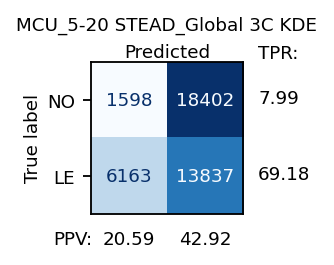

In [1]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging

if __name__ == "__main__":
                    
    #===================================================================
    #                    1. KONFIGURASI PATH STEAD
    #===================================================================
    # Path dataset STEAD yang Bapak berikan
    KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead"
    KEY_TEST_FILE = "STEAD_10000_Harmonized_Final.json" 
    
    DATA_TAG = "STEAD_Global"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    # STEAD fokus pada Noise (NO) dan Earthquake (LE)
    true_labels = ["NO", "LE"]
    source_to_code = {"noise": 0, "le": 1}

    # Path Model dan Embedding (PASTIKAN MENGGUNAKAN EMBEDDING STEAD)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Path Embedding Khusus STEAD (n=61099)
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")

    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    print(f"[INFO] Memuat Dataset STEAD: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo"
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_stead_global.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings STEAD
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating STEAD Global embeddings statistics (KDE)...")
    # Menggunakan statistik ruang laten STEAD
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    #===================================================================
    #                            3. EVALUATION
    #===================================================================
    total_true_3C, total_pred_3C = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data STEAD...")

    for i in tqdm(range(len(keys_list)), desc="Inference STEAD"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"] # label asli: 'le'
    
        try:
            # Sinyal & Noise 3C
            Z_n, N_n, E_n = record["Z_noise"][-num_points:], record["N_noise"][-num_points:], record["E_noise"][-num_points:]
            Z_s, N_s, E_s = record["Z"][:num_points], record["N"][:num_points], record["E"][:num_points]

            # Embeddings
            _in_Zn, _in_Nn, _in_En = utils.latent_codes_1D(Z_n, embedding_model), utils.latent_codes_1D(N_n, embedding_model), utils.latent_codes_1D(E_n, embedding_model)
            _in_Zs, _in_Ns, _in_Es = utils.latent_codes_1D(Z_s, embedding_model), utils.latent_codes_1D(N_s, embedding_model), utils.latent_codes_1D(E_s, embedding_model)

            # Inferensi 3C KDE - Noise
            emb_n_3c = np.array([_in_En, _in_Nn, _in_Zn]).reshape(1,-1)
            p_n_3c, _, _ = utils.infer_3C_PDFs(emb_n_3c, embeddings_3C_PDFs, "Kernel")
            
            # Inferensi 3C KDE - Earthquake
            emb_s_3c = np.array([_in_Es, _in_Ns, _in_Zs]).reshape(1,-1)
            p_s_3c, _, _ = utils.infer_3C_PDFs(emb_s_3c, embeddings_3C_PDFs, "Kernel")

            # Mapping Label STEAD (Biner: NO vs LE)
            # Di STEAD, output model index 1 (QB) atau 2 (LE) dianggap sebagai Earthquake (1)
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n_3c >= 1 else 0, 1 if p_s_3c >= 1 else 0])
            
        except KeyError:
            continue

    #===================================================================
    #                        4. METRICS & SAVE
    #===================================================================
    matrix_3C, metrics_3C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
    
    # Visualisasi
    fig_3C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 3C KDE", true_labels, matrix_3C, metrics_3C)
    fig_3C.savefig(os.path.join(save_dir, "STEAD_Global_3C_KDE.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, "stead_global_metrics.json"), metrics_3C)
    
    logger.info("\n" + "="*40)
    logger.info(f"STEAD GLOBAL ACCURACY: {metrics_3C.get('accuracy (avg.)')}")
    logger.info(f"STEAD GLOBAL F1-SCORE: {metrics_3C.get('f1-score (avg.)')}")
    logger.info("="*40)
    logger.info("Pengujian STEAD Selesai.")